## 5. Implement and compare RNN, LSTM, and GRU models for sequence classification, and analyze their performance using appropriate evaluation metrics

## Install Required Libraries

In [ ]:
!pip install tensorflow numpy pandas matplotlib scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## Load IMDB Dataset
The IMDB dataset contains movie reviews labeled as either positive or
negative.

- Label 0 → Negative review
- Label 1 → Positive review

The dataset is already converted into sequences of integer word indexes,
which makes it suitable for recurrent neural network models.

In [3]:
# Number of most frequent words to keep
vocab_size = 10000

# Load IMDB dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training samples: 25000
Testing samples: 25000


## Understand the Dataset

Each movie review is represented as a sequence of integer values.
Different reviews have different sequence lengths.
The sequence lengths are analyzed before padding the data.

In [4]:
print("First training sequence:")
print(X_train[0])

print("\nFirst training label:")
print(y_train[0])

print("\nLength of first sequence:")
print(len(X_train[0]))

print("\nMinimum sequence length:",
      min(len(sequence) for sequence in X_train))

print("Maximum sequence length:",
      max(len(sequence) for sequence in X_train))

First training sequence:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

First training label:
1

Length of

## Analyze Class Distribution

The number of positive and negative reviews is checked to understand
the class distribution of the dataset.

In [5]:
unique, counts = np.unique(y_train, return_counts=True)

print("Class distribution:")

for label, count in zip(unique, counts):
    if label == 0:
        print("Negative:", count)
    else:
        print("Positive:", count)

Class distribution:
Negative: 12500
Positive: 12500


## Visualize Review Sequence Lengths

A histogram is plotted to visualize the distribution of review lengths.
This helps in selecting an appropriate sequence length for padding.

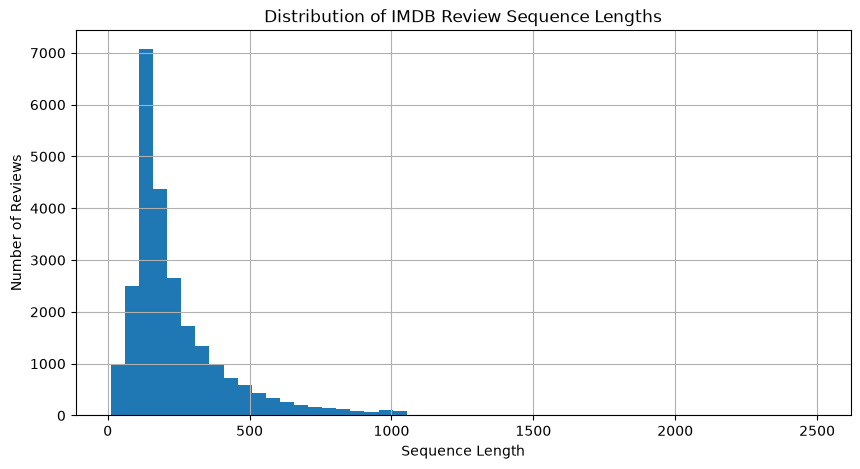

In [6]:
train_lengths = [len(sequence) for sequence in X_train]

plt.figure(figsize=(10, 5))

plt.hist(train_lengths, bins=50)

plt.title("Distribution of IMDB Review Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Number of Reviews")

plt.grid(True)
plt.show()

## Pad the Sequences

Since different reviews have different lengths, padding is used to make
all sequences the same length.
A maximum sequence length of 200 is selected. Reviews shorter than 200 tokens are padded, while longer reviews are truncated.

In [7]:
max_length = 200

X_train_padded = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training data shape:", X_train_padded.shape)
print("Testing data shape:", X_test_padded.shape)

Training data shape: (25000, 200)
Testing data shape: (25000, 200)


## Build the Simple RNN Model

A Simple Recurrent Neural Network (RNN) is implemented as the first
sequence classification model. The Embedding layer converts word indexes into dense vector representations. The SimpleRNN layer processes the sequence, and the Dense layer performs binary classification.

In [8]:
def build_rnn_model():
    
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=64,
            input_length=max_length
        ),
        
        SimpleRNN(64),
        
        Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model


rnn_model = build_rnn_model()

rnn_model.summary()

C:\Users\Aksha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the Simple RNN Model

The Simple RNN model is trained using the training dataset.
Validation data is used to monitor the model's performance during training.

In [9]:
rnn_history = rnn_model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.5056 - loss: 0.6953 - val_accuracy: 0.4962 - val_loss: 0.6958
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.5660 - loss: 0.6773 - val_accuracy: 0.4950 - val_loss: 0.7035
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.6434 - loss: 0.5856 - val_accuracy: 0.4988 - val_loss: 0.7636
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.7230 - loss: 0.4397 - val_accuracy: 0.4976 - val_loss: 0.9177
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.7467 - loss: 0.3835 - val_accuracy: 0.4956 - val_loss: 1.0339


## Build the LSTM Model

Long Short-Term Memory (LSTM) is an improved recurrent architecture
designed to handle long-term dependencies in sequential data. LSTM uses memory cells and gates to control the flow of information.

In [10]:
def build_lstm_model():
    
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=64,
            input_length=max_length
        ),
        
        LSTM(64),
        
        Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model


lstm_model = build_lstm_model()

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the LSTM Model

The LSTM model is trained using the same training data and training
configuration used for the RNN model. Using the same conditions provides a fair comparison between models.

In [11]:
lstm_history = lstm_model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 165ms/step - accuracy: 0.5546 - loss: 0.6791 - val_accuracy: 0.7124 - val_loss: 0.5996
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 170ms/step - accuracy: 0.5735 - loss: 0.6721 - val_accuracy: 0.5356 - val_loss: 0.6899
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 167ms/step - accuracy: 0.5965 - loss: 0.6540 - val_accuracy: 0.5184 - val_loss: 0.6984
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.6726 - loss: 0.6186 - val_accuracy: 0.5412 - val_loss: 0.6869
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 151ms/step - accuracy: 0.7042 - loss: 0.5640 - val_accuracy: 0.7150 - val_loss: 0.5909


## Build the GRU Model

Gated Recurrent Unit (GRU) is another recurrent neural network
architecture that uses gates to control information flow. GRU is generally simpler than LSTM because it uses fewer gates while
still being able to learn long-term dependencies.

In [12]:
def build_gru_model():
    
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=64,
            input_length=max_length
        ),
        
        GRU(64),
        
        Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model


gru_model = build_gru_model()

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the GRU Model

The GRU model is trained using the same dataset and training
configuration used for the RNN and LSTM models.

In [13]:
gru_history = gru_model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 136ms/step - accuracy: 0.5100 - loss: 0.6922 - val_accuracy: 0.5422 - val_loss: 0.6881
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.6265 - loss: 0.6257 - val_accuracy: 0.7904 - val_loss: 0.4802
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.8239 - loss: 0.4213 - val_accuracy: 0.8252 - val_loss: 0.4203
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 136ms/step - accuracy: 0.8971 - loss: 0.2681 - val_accuracy: 0.8528 - val_loss: 0.3629
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.9420 - loss: 0.1677 - val_accuracy: 0.8500 - val_loss: 0.3816


## Compare Training Accuracy
The training accuracy of RNN, LSTM, and GRU is compared to understand how the models learn the sequence classification task.


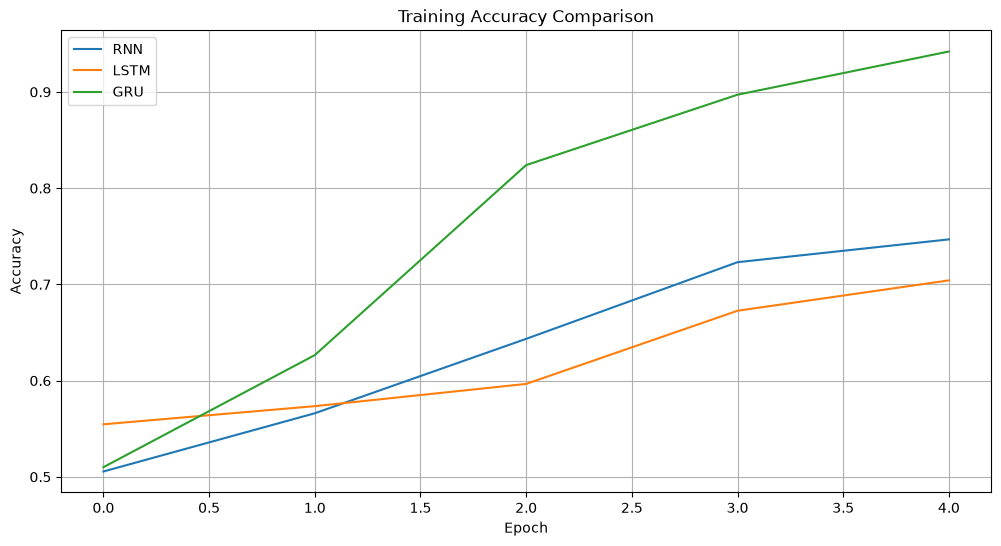

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(
    rnn_history.history["accuracy"],
    label="RNN"
)

plt.plot(
    lstm_history.history["accuracy"],
    label="LSTM"
)

plt.plot(
    gru_history.history["accuracy"],
    label="GRU"
)

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

## Compare Validation Accuracy

Validation accuracy is compared to determine how well each model
generalizes to unseen validation data.

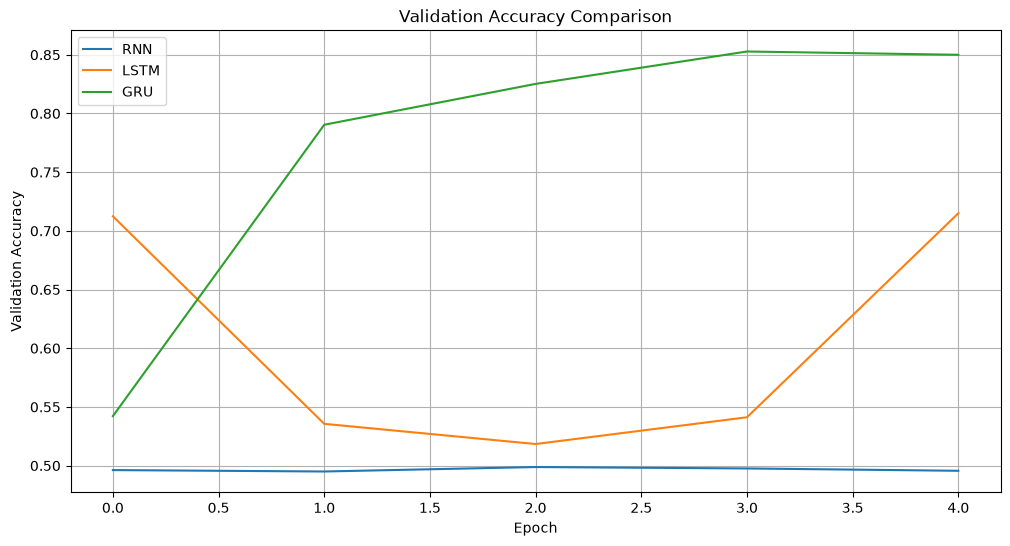

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    rnn_history.history["val_accuracy"],
    label="RNN"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="LSTM"
)

plt.plot(
    gru_history.history["val_accuracy"],
    label="GRU"
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

## Generate Predictions

The trained RNN, LSTM, and GRU models are used to predict the classes
of the unseen test reviews.

In [16]:
rnn_probabilities = rnn_model.predict(X_test_padded)
lstm_probabilities = lstm_model.predict(X_test_padded)
gru_probabilities = gru_model.predict(X_test_padded)

rnn_predictions = (rnn_probabilities >= 0.5).astype(int).flatten()
lstm_predictions = (lstm_probabilities >= 0.5).astype(int).flatten()
gru_predictions = (gru_probabilities >= 0.5).astype(int).flatten()

print("Predictions generated successfully.")

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step
Predictions generated successfully.


## Evaluate Model Performance

The models are evaluated using four important classification metrics:

- Accuracy
- Precision
- Recall
- F1-score

These metrics provide a comprehensive comparison of the three models.

In [17]:
def evaluate_model(model_name, y_true, y_pred):
    
    accuracy = accuracy_score(y_true, y_pred)
    
    precision = precision_score(y_true, y_pred)
    
    recall = recall_score(y_true, y_pred)
    
    f1 = f1_score(y_true, y_pred)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }


rnn_results = evaluate_model(
    "RNN",
    y_test,
    rnn_predictions
)

lstm_results = evaluate_model(
    "LSTM",
    y_test,
    lstm_predictions
)

gru_results = evaluate_model(
    "GRU",
    y_test,
    gru_predictions
)

results = pd.DataFrame([
    rnn_results,
    lstm_results,
    gru_results
])

results

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.50524,0.503669,0.71928,0.592468
1,LSTM,0.70052,0.776992,0.56248,0.652559
2,GRU,0.84004,0.855899,0.81776,0.836395


## Performance Comparison

The evaluation metrics of RNN, LSTM, and GRU are visualized to make
the performance differences easier to analyze.

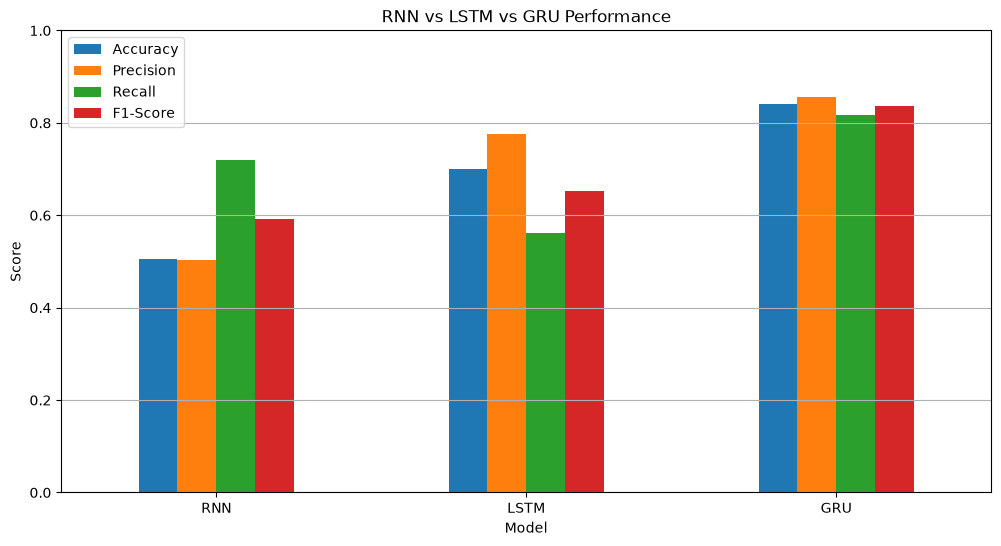

In [18]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("RNN vs LSTM vs GRU Performance")
plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

## Confusion Matrix

Confusion matrices are generated for all three models.
The confusion matrix shows the number of correctly and incorrectly
classified positive and negative reviews.

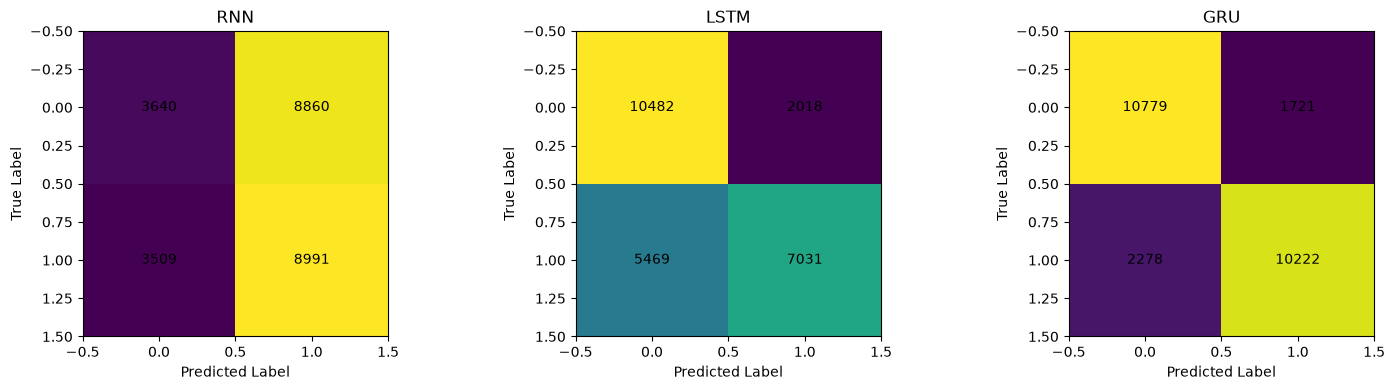

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_predictions = [
    ("RNN", rnn_predictions),
    ("LSTM", lstm_predictions),
    ("GRU", gru_predictions)
]

for ax, (name, predictions) in zip(axes, models_predictions):
    
    cm = confusion_matrix(y_test, predictions)
    
    ax.imshow(cm)
    
    ax.set_title(name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    
    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()

## Classification Report

In [20]:
print("=" * 60)
print("RNN CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        rnn_predictions,
        target_names=["Negative", "Positive"]
    )
)


print("=" * 60)
print("LSTM CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        lstm_predictions,
        target_names=["Negative", "Positive"]
    )
)


print("=" * 60)
print("GRU CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        gru_predictions,
        target_names=["Negative", "Positive"]
    )
)

RNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.51      0.29      0.37     12500
    Positive       0.50      0.72      0.59     12500

    accuracy                           0.51     25000
   macro avg       0.51      0.51      0.48     25000
weighted avg       0.51      0.51      0.48     25000

LSTM CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.66      0.84      0.74     12500
    Positive       0.78      0.56      0.65     12500

    accuracy                           0.70     25000
   macro avg       0.72      0.70      0.69     25000
weighted avg       0.72      0.70      0.69     25000

GRU CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.83      0.86      0.84     12500
    Positive       0.86      0.82      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     2

## Identify the Best Performing Model

The model with the highest F1-score is selected as the best-performing
model because F1-score considers both precision and recall.

In [21]:
best_model = results.loc[
    results["F1-Score"].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model             GRU
Accuracy      0.84004
Precision    0.855899
Recall        0.81776
F1-Score     0.836395
Name: 2, dtype: object


## Final Results

The performance of RNN, LSTM, and GRU is compared using Accuracy,
Precision, Recall, and F1-score. The model with the highest evaluation score provides the best performance for the IMDB sequence classification task.

In [22]:
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

print(results.to_string(index=False))

print("\nBest Model based on F1-Score:")
print(best_model["Model"])

print(f"\nBest F1-Score: {best_model['F1-Score']:.4f}")

FINAL MODEL COMPARISON
Model  Accuracy  Precision  Recall  F1-Score
  RNN   0.50524   0.503669 0.71928  0.592468
 LSTM   0.70052   0.776992 0.56248  0.652559
  GRU   0.84004   0.855899 0.81776  0.836395

Best Model based on F1-Score:
GRU

Best F1-Score: 0.8364
